In [1]:
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
data = pd.read_csv('data_science_job.csv')

In [4]:
data.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [32]:
data.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), str(8)
memory usage: 3.2 MB


In [33]:
data.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [34]:
col = [col for col in data.columns if data[col].isnull().mean() < 0.05 and data[col].isnull().mean() > 0]
col

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

<Axes: ylabel='Density'>

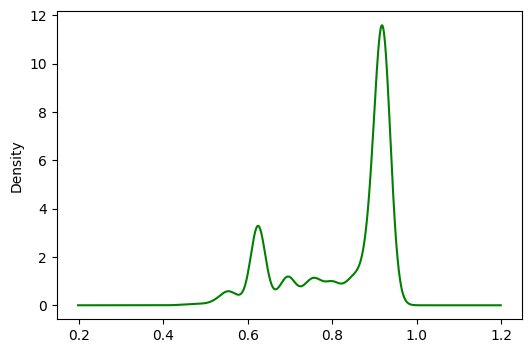

In [35]:
fig = plt.figure(figsize=(6,4))

ax = fig.add_subplot(111)

data['city_development_index'].plot(kind='kde', ax=ax, color='green')

In [36]:
new_data = data[col]

new_data.head()

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
3,0.789,NaN,Graduate,0.0,52.0
4,0.767,no_enrollment,Masters,20.0,8.0


## Filling 'city_development_index' with mean and median

In [37]:
new_data['city_development_index_mean'] = new_data['city_development_index'].fillna(new_data['city_development_index'].mean())
new_data['city_development_index_median'] = new_data['city_development_index'].fillna(new_data['city_development_index'].median())

In [38]:
new_data.head()

,city_development_index,enrolled_university,education_level,experience,training_hours,city_development_index_mean,city_development_index_median
0,0.920,no_enrollment,Graduate,20.0,36.0,0.920,0.920
1,0.776,no_enrollment,Graduate,15.0,47.0,0.776,0.776
2,0.624,Full time course,Graduate,5.0,83.0,0.624,0.624
3,0.789,NaN,Graduate,0.0,52.0,0.789,0.789
4,0.767,no_enrollment,Masters,20.0,8.0,0.767,0.767


In [39]:
print('Original city_development_index variable variance: ', data['city_development_index'].var())
print('city_development_index Variance after median imputation: ', new_data['city_development_index_median'].var())
print('city_development_index Variance after mean imputation: ', new_data['city_development_index_mean'].var())


Original city_development_index variable variance:  0.015211374664424404
city_development_index Variance after median imputation:  0.014964705977771617
city_development_index Variance after mean imputation:  0.01483103074500804


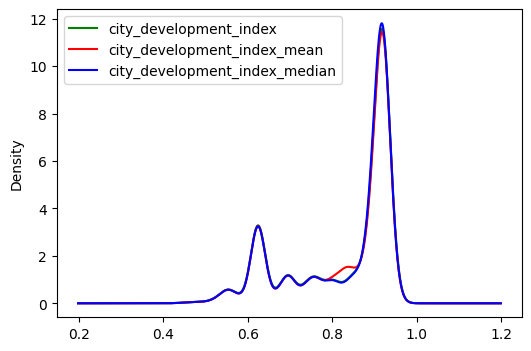

In [40]:
fig = plt.figure(figsize=(6,4))

ax = fig.add_subplot(111)

data['city_development_index'].plot(kind='kde', ax=ax, color='green')
new_data['city_development_index_mean'].plot(kind='kde', ax=ax, color='red')
new_data['city_development_index_median'].plot(kind='kde', ax=ax, color='blue')



lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

plt.show()

<Axes: >

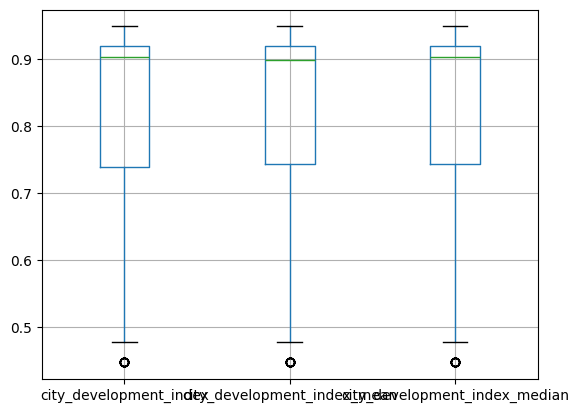

In [41]:
new_data[['city_development_index', 'city_development_index_mean', 'city_development_index_median']].boxplot()

## Filling 'experience' with mean and median

<Axes: ylabel='Density'>

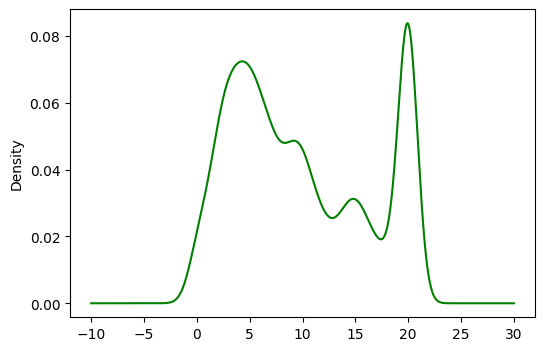

In [42]:
fig = plt.figure(figsize=(6,4))

ax = fig.add_subplot(111)

data['experience'].plot(kind='kde', ax=ax, color='green')

In [43]:
new_data['experience_mean'] = new_data['experience'].fillna(new_data['experience'].mean())
new_data['experience_median'] = new_data['experience'].fillna(new_data['experience'].median())

In [44]:
new_data.head()

,city_development_index,enrolled_university,education_level,experience,training_hours,city_development_index_mean,city_development_index_median,experience_mean,experience_median
0,0.920,no_enrollment,Graduate,20.0,36.0,0.920,0.920,20.0,20.0
1,0.776,no_enrollment,Graduate,15.0,47.0,0.776,0.776,15.0,15.0
2,0.624,Full time course,Graduate,5.0,83.0,0.624,0.624,5.0,5.0
3,0.789,NaN,Graduate,0.0,52.0,0.789,0.789,0.0,0.0
4,0.767,no_enrollment,Masters,20.0,8.0,0.767,0.767,20.0,20.0


In [19]:
print('Original experience variable variance: ', data['experience'].var())
print('experience Variance after median imputation: ', new_data['experience_median'].var())
print('experience Variance after mean imputation: ', new_data['experience_mean'].var())


Original experience variable variance:  42.318516765484425
experience Variance after median imputation:  42.17784170322686
experience Variance after mean imputation:  42.17492937759715


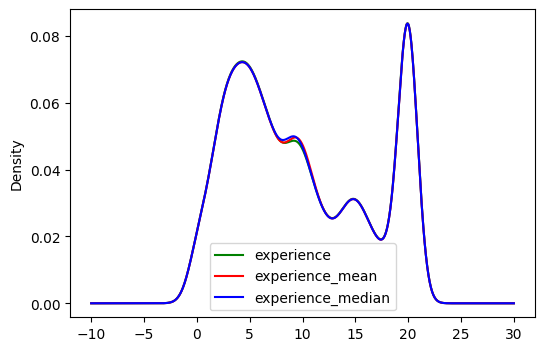

In [45]:
fig = plt.figure(figsize=(6,4))

ax = fig.add_subplot(111)

data['experience'].plot(kind='kde', ax=ax, color='green')
new_data['experience_mean'].plot(kind='kde', ax=ax, color='red')
new_data['experience_median'].plot(kind='kde', ax=ax, color='blue')



lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

plt.show()

<Axes: >

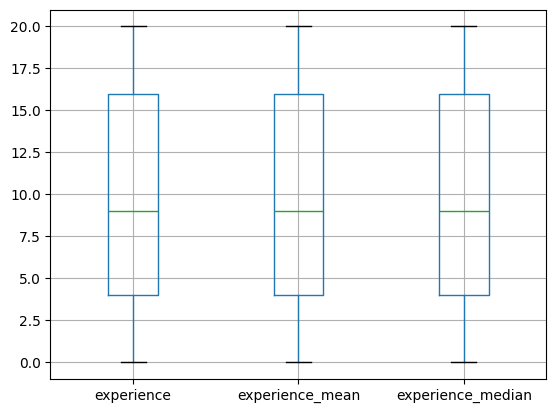

In [46]:
new_data[['experience', 'experience_mean', 'experience_median']].boxplot()

## Filing 'training_hours' with mean and median

<Axes: ylabel='Density'>

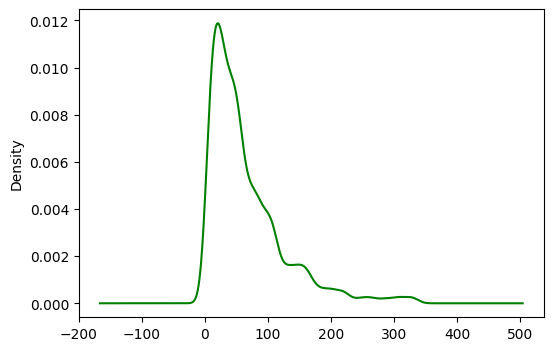

In [22]:
fig = plt.figure(figsize=(6,4))

ax = fig.add_subplot(111)

data['training_hours'].plot(kind='kde', ax=ax, color='green')

In [23]:
new_data['training_hours_mean'] = new_data['training_hours'].fillna(new_data['training_hours'].mean())
new_data['training_hours_median'] = new_data['training_hours'].fillna(new_data['training_hours'].median())

In [24]:
new_data.head()

,city_development_index,enrolled_university,education_level,experience,training_hours,city_development_index_mean,city_development_index_median,experience_mean,experience_median,training_hours_mean,training_hours_median
0,0.920,no_enrollment,Graduate,20.0,36.0,0.920,0.920,20.0,20.0,36.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0,0.776,0.776,15.0,15.0,47.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0,0.624,0.624,5.0,5.0,83.0,83.0
3,0.789,NaN,Graduate,0.0,52.0,0.789,0.789,0.0,0.0,52.0,52.0
4,0.767,no_enrollment,Masters,20.0,8.0,0.767,0.767,20.0,20.0,8.0,8.0


In [25]:
print('Original training_hours variable variance: ', data['training_hours'].var())
print('training_hours Variance after median imputation: ', new_data['training_hours_median'].var())
print('training_hours Variance after mean imputation: ', new_data['training_hours_mean'].var())


Original training_hours variable variance:  3586.2881933989406
training_hours Variance after median imputation:  3455.5844212756538
training_hours Variance after mean imputation:  3442.889083092338


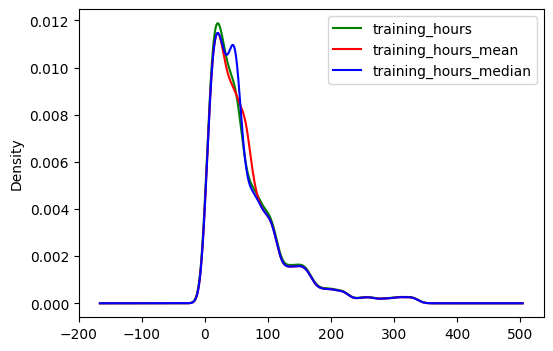

In [26]:
fig = plt.figure(figsize=(6,4))

ax = fig.add_subplot(111)

data['training_hours'].plot(kind='kde', ax=ax, color='green')
new_data['training_hours_mean'].plot(kind='kde', ax=ax, color='red')
new_data['training_hours_median'].plot(kind='kde', ax=ax, color='blue')



lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

plt.show()

<Axes: >

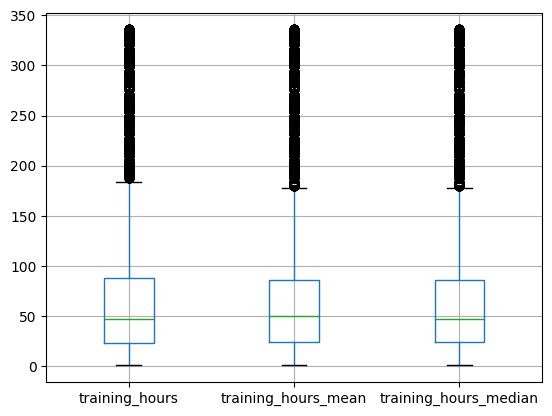

In [30]:
new_data[['training_hours', 'training_hours_mean', 'training_hours_median']].boxplot()

In [28]:
new_data[['city_development_index', 'experience', 'training_hours', 'city_development_index_mean', 'city_development_index_median']].cov()

,city_development_index,experience,training_hours,city_development_index_mean,city_development_index_median
city_development_index,0.015211,0.266895,-0.015343,0.015211,0.015211
experience,0.266895,42.318517,-0.317638,0.260227,0.260418
training_hours,-0.015343,-0.317638,3586.288193,-0.014950,-0.015598
city_development_index_mean,0.015211,0.260227,-0.014950,0.014831,0.014831
city_development_index_median,0.015211,0.260418,-0.015598,0.014831,0.014965


In [29]:
new_data[['city_development_index', 'experience', 'training_hours', 'city_development_index_mean', 'city_development_index_median']].corr()

,city_development_index,experience,training_hours,city_development_index_mean,city_development_index_median
city_development_index,1.000000,0.333050,-0.002083,1.000000,1.000000
experience,0.333050,1.000000,-0.000815,0.328762,0.327538
training_hours,-0.002083,-0.000815,1.000000,-0.002054,-0.002134
city_development_index_mean,1.000000,0.328762,-0.002054,1.000000,0.995524
city_development_index_median,1.000000,0.327538,-0.002134,0.995524,1.000000


In [82]:
new_data1 = data[col].copy()

new_data1.head()

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
3,0.789,NaN,Graduate,0.0,52.0
4,0.767,no_enrollment,Masters,20.0,8.0


In [83]:
new_data1['training_hours_constant'] = new_data1['training_hours'].fillna(400)

In [84]:
new_data1.head()

,city_development_index,enrolled_university,education_level,experience,training_hours,training_hours_constant
0,0.920,no_enrollment,Graduate,20.0,36.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0,83.0
3,0.789,NaN,Graduate,0.0,52.0,52.0
4,0.767,no_enrollment,Masters,20.0,8.0,8.0


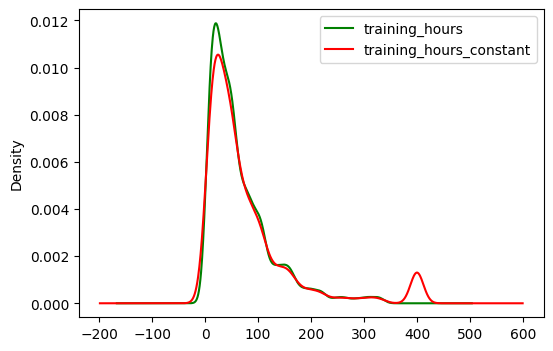

In [85]:
fig = plt.figure(figsize=(6,4))

ax = fig.add_subplot(111)

data['training_hours'].plot(kind='kde', ax=ax, color='green')
new_data1['training_hours_constant'].plot(kind='kde', ax=ax, color='red')




lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

plt.show()

<Axes: >

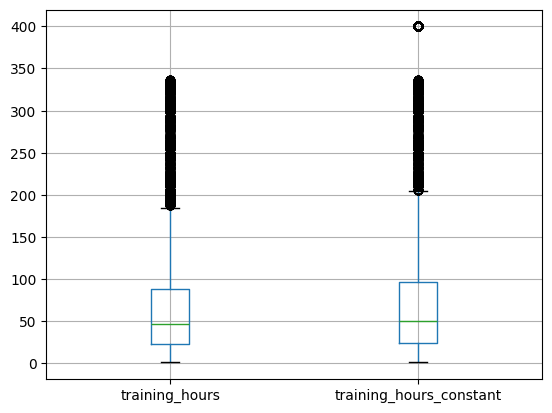

In [86]:
new_data1[['training_hours', 'training_hours_constant']].boxplot()

## Using sklearn for 'training_hours'

In [68]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [70]:
si = SimpleImputer(strategy='constant', fill_value=99)

In [71]:
ct = ColumnTransformer([
    ('imputer', si, ['training_hours'])
], remainder='passthrough')

In [72]:
ct.fit(new_data1)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""

In [74]:
new_data1.isnull().sum()

city_development_index    479
enrolled_university       386
education_level           460
experience                 65
training_hours            766
dtype: int64

In [52]:
df = new_data[['city_development_index_mean', 'experience_mean', 'training_hours']]

In [53]:
df.isnull().sum()

city_development_index_mean      0
experience_mean                  0
training_hours                 766
dtype: int64

In [54]:
from sklearn.impute import KNNImputer

In [70]:
kni = KNNImputer(n_neighbors=3, weights='distance')

In [71]:
training_hours_impute = kni.fit_transform(df)

In [72]:
df.sample(10)

,city_development_index_mean,experience_mean,training_hours
4141,0.855,6.0,166.0
5,0.764,11.0,24.0
9984,0.920,13.0,NaN
14096,0.910,18.0,39.0
11532,0.926,20.0,110.0
17974,0.624,11.0,12.0
8370,0.550,3.0,210.0
7628,0.624,5.0,156.0
8986,0.910,1.0,106.0
14185,0.899,20.0,34.0


In [73]:
df1 = pd.DataFrame(training_hours_impute, columns=['city_development_index_mean', 'experience_mean', 'training_hours_impute'])

In [74]:
df1.sample(10)

,city_development_index_mean,experience_mean,training_hours_impute
7003,0.923,10.0,196.0
18753,0.949,11.0,45.0
8239,0.920,5.0,82.0
18708,0.624,3.0,42.0
13061,0.920,20.0,60.0
15001,0.939,6.0,12.0
6171,0.920,7.0,12.0
13817,0.550,2.0,48.0
10405,0.754,2.0,38.0
1902,0.899,6.0,28.0


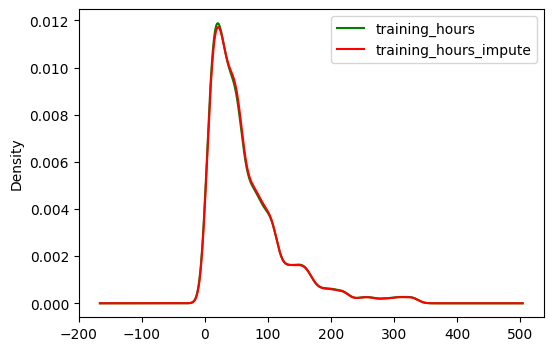

In [75]:
fig = plt.figure(figsize=(6,4))

ax = fig.add_subplot(111)

data['training_hours'].plot(kind='kde', ax=ax, color='green')
df1['training_hours_impute'].plot(kind='kde', ax=ax, color='red')




lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

plt.show()

<Axes: >

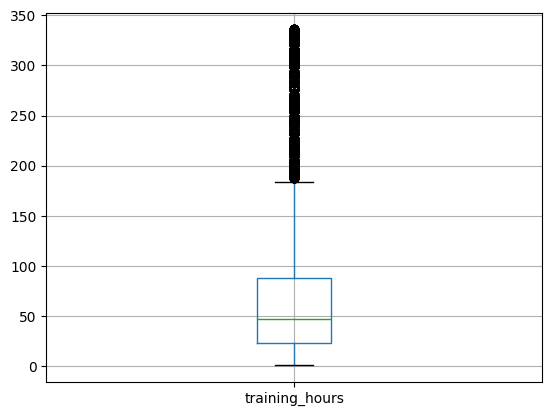

In [80]:
data[['training_hours']].boxplot()


<Axes: >

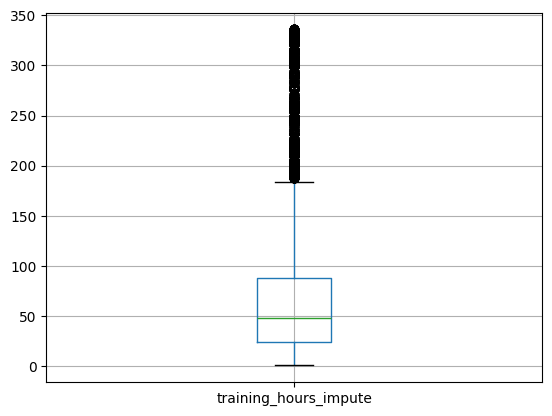

In [79]:
df1[['training_hours_impute']].boxplot()